In [32]:
import random

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from utils.config import Config
from data_handler import DataHandler
# from classificators.dummy_classifier import DummyClassifier
# from classificators.random_forest_classifier import RandomForestClassifierSK
# from utils.utils import calculate_mcc_multilabel, plot_per_class_confusion


In [29]:
config = Config()

# Seeding
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# if you use any other libraries that require seeding, set it here as well (e.g., torch.manual_seed(SEED) for PyTorch)
# -> your results should be reproducible across runs with the same seed


val_mccs = []
test_mccs = []
lr_histories_by_fold = {}

# load data
datahandler = DataHandler(config=config)


Local dataset found: data\cps_data_multi_label.pkl
Loading data into memory...
Data loaded.


In [34]:

# Leave-one-out: EXPERIMENT_ID = 1..4
for fold in range(1, 2):
    val_id = fold + 1 if fold < 4 else 1

    datahandler.config.data.test_experiment_id = fold
    # validation hat to be different from test
    datahandler.config.data.validation_experiment_id = val_id

    train, val, test, target_vals = datahandler.get_data_loaders()
    print("Full Data Shape")
    print(train.shape, val.shape, test.shape)
    print("Target columns:", target_vals)
    print("Train columns:", train.columns.tolist())
    X_train = train.iloc[:, :8]
    y_train = train.iloc[:, 8:]
    X_val = val.iloc[:, :8]
    y_val = val.iloc[:, 8:]
    X_test = test.iloc[:, :8]
    y_test = test.iloc[:, 8:]

Starting data preparation...
Full Data Shape
(2136599, 15) (941667, 15) (1108546, 15)
Target columns: ['Driving(curve)', 'Driving(straight)', 'Lifting(lowering)', 'Lifting(raising)', 'Stationary processes', 'Turntable wrapping']
Train columns: ['time', 'Acc.x', 'Acc.y', 'Acc.z', 'Gyro.x', 'Gyro.y', 'Gyro.z', 'Baro.x', 'No loading', 'Driving(straight)', 'Driving(curve)', 'Lifting(raising)', 'Lifting(lowering)', 'Turntable wrapping', 'Stationary processes']


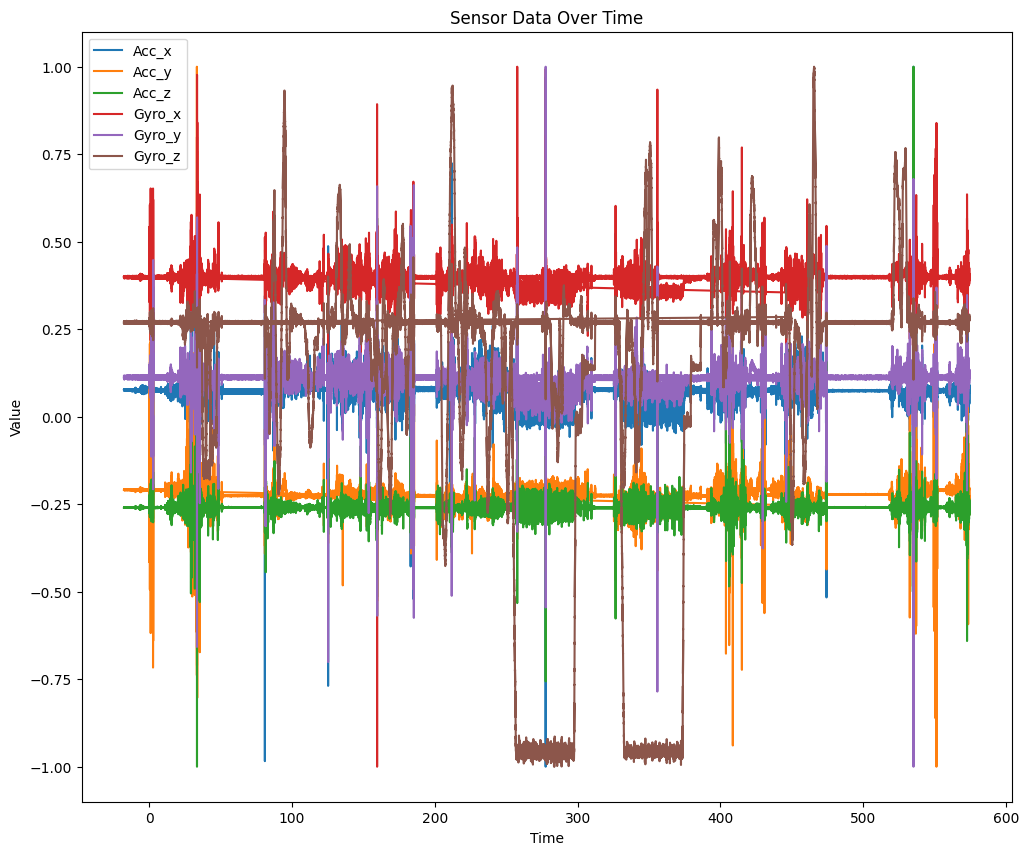

In [38]:
plt.figure(figsize=(12, 10))
plt.plot(X_train['time'], X_train['Acc.x'], label='Acc_x')
plt.plot(X_train['time'], X_train['Acc.y'], label='Acc_y')
plt.plot(X_train['time'], X_train['Acc.z'], label='Acc_z')
plt.plot(X_train['time'], X_train['Gyro.x'], label='Gyro_x')
plt.plot(X_train['time'], X_train['Gyro.y'], label='Gyro_y')
plt.plot(X_train['time'], X_train['Gyro.z'], label='Gyro_z')
# plt.plot(X_train['time'], X_train['Baro.x'], label='Baro_x')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Sensor Data Over Time')
plt.legend()
plt.show()
